Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total Sentences Loaded: 13306


100%|██████████| 1000/1000 [16:12<00:00,  1.03it/s]



Saved: layer_head_scores.csv

AVERAGE SCORE BY LAYER
    Layer  Accuracy
0       1  0.243820
1       2  0.201114
2       3  0.262903
3       4  0.251818
4       5  0.268840
5       6  0.328422
6       7  0.370736
7       8  0.260864
8       9  0.285710
9      10  0.282546
10     11  0.245876
11     12  0.188531

BEST HEAD IN EACH LAYER

Layer 1
Layer       1.000000
Head        7.000000
Accuracy    0.543425
Name: 6, dtype: float64

Layer 2
Layer       2.000000
Head        5.000000
Accuracy    0.440591
Name: 16, dtype: float64

Layer 3
Layer       3.000000
Head        4.000000
Accuracy    0.515371
Name: 27, dtype: float64

Layer 4
Layer       4.000000
Head        2.000000
Accuracy    0.425491
Name: 37, dtype: float64

Layer 5
Layer       5.000000
Head        3.000000
Accuracy    0.433054
Name: 50, dtype: float64

Layer 6
Layer       6.000000
Head        9.000000
Accuracy    0.602727
Name: 68, dtype: float64

Layer 7
Layer       7.000000
Head        9.000000
Accuracy    0.610113
Name: 80

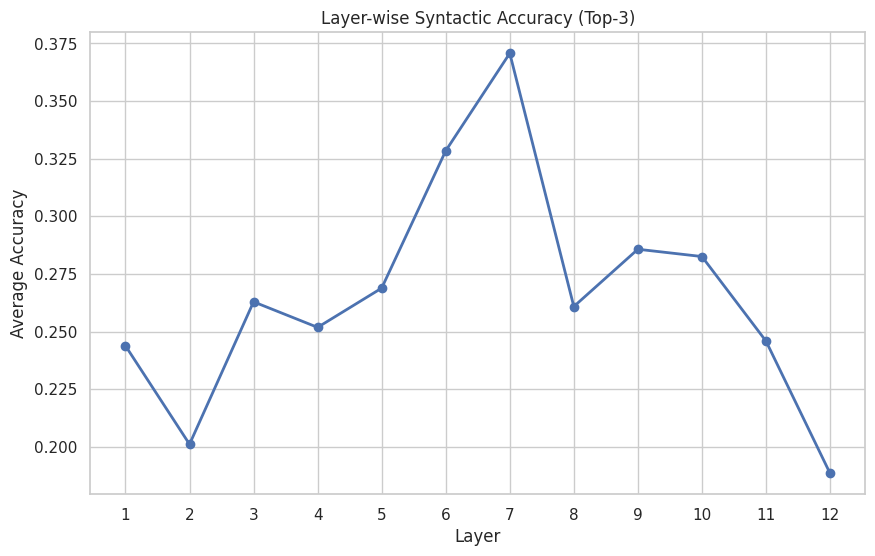

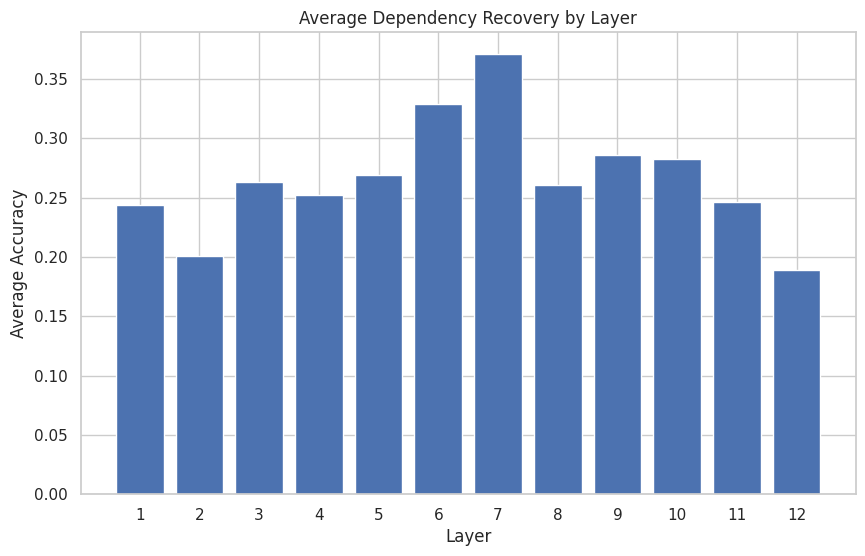

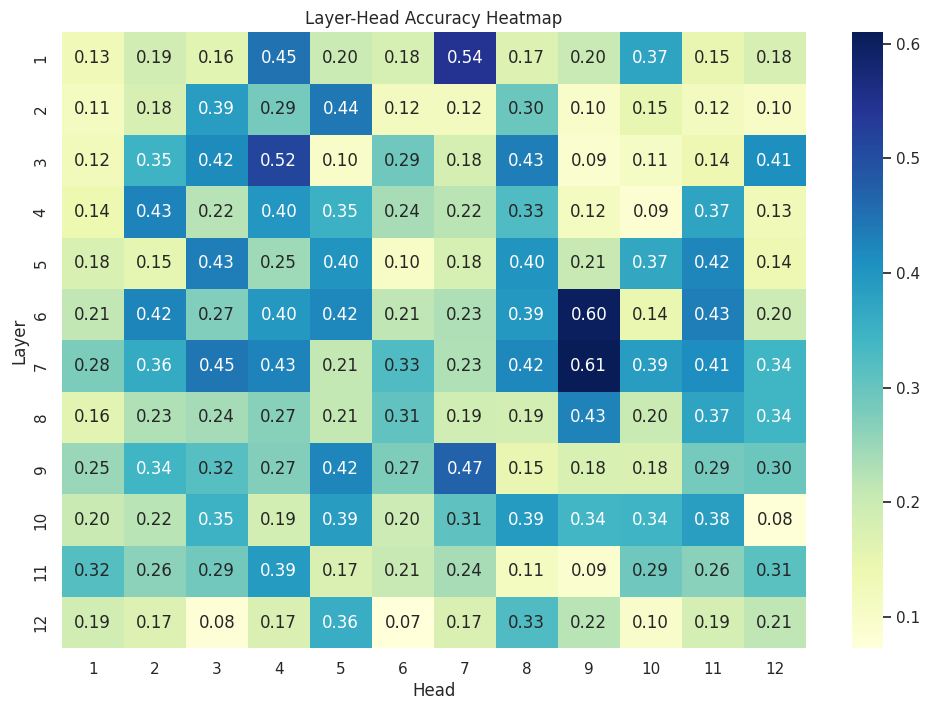


BEST OVERALL HEAD
Layer       7.000000
Head        9.000000
Accuracy    0.610113
Name: 80, dtype: float64


In [1]:

# LAYER-WISE ANALYSIS PIPELINE (BERT + UD DATASET)


!pip -q install transformers torch conllu requests seaborn matplotlib pandas numpy tqdm


import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from tqdm import tqdm
from conllu import parse
from transformers import BertTokenizer, BertModel

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


MODEL_NAME = "bert-base-multilingual-cased"


DATASET_URL = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu"

NUM_SENTENCES = 1000
MAX_LEN_WORDS = 40


tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

model = BertModel.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.to(device)
model.eval()


print("Downloading dataset...")

data = requests.get(DATASET_URL).text
sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))


def tokenize_with_alignment(words):

    bert_tokens = ["[CLS]"]
    mapping = {}

    pos = 1

    for i, word in enumerate(words, start=1):

        subs = tokenizer.tokenize(word)

        if len(subs) == 0:
            subs = ["[UNK]"]

        mapping[i] = list(range(pos, pos + len(subs)))

        bert_tokens.extend(subs)
        pos += len(subs)

    bert_tokens.append("[SEP]")

    return bert_tokens, mapping



def get_attention(words):

    sent = " ".join(words)

    inputs = tokenizer(
        sent,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.attentions



def convert_to_word_matrix(token_matrix, mapping, n_words):

    word_matrix = np.zeros((n_words+1, n_words+1))

    for child in range(1, n_words+1):

        child_tokens = mapping[child]

        for parent in range(1, n_words+1):

            parent_tokens = mapping[parent]

            vals = []

            for ct in child_tokens:
                for pt in parent_tokens:
                    vals.append(token_matrix[ct][pt])

            word_matrix[child][parent] = np.mean(vals)

    return word_matrix



def top3_score(word_matrix, heads):

    correct = 0
    total = 0

    n = len(heads)

    for child in range(1, n+1):

        gold_parent = heads[child-1]

        if gold_parent == 0:
            continue

        row = word_matrix[child][1:]   

        top3 = np.argsort(row)[-3:] + 1

        if gold_parent in top3:
            correct += 1

        total += 1

    if total == 0:
        return None

    return correct / total



results = []

for idx in tqdm(range(min(NUM_SENTENCES, len(sentences)))):

    try:
        sent = sentences[idx]

        words = []
        heads = []

        for tok in sent:
            if isinstance(tok["id"], int):
                words.append(tok["form"])
                heads.append(tok["head"])

        if len(words) < 3:
            continue

        if len(words) > MAX_LEN_WORDS:
            continue

        attentions = get_attention(words)

        _, mapping = tokenize_with_alignment(words)

        n_words = len(words)

        for layer in range(12):
            for head in range(12):

                token_matrix = attentions[layer][0, head].cpu().numpy()

                word_matrix = convert_to_word_matrix(
                    token_matrix,
                    mapping,
                    n_words
                )

                score = top3_score(word_matrix, heads)

                if score is not None:
                    results.append([
                        layer+1,
                        head+1,
                        score
                    ])

    except:
        continue


df = pd.DataFrame(
    results,
    columns=["Layer", "Head", "Accuracy"]
)

avg_df = df.groupby(
    ["Layer", "Head"]
)["Accuracy"].mean().reset_index()


avg_df.to_csv("layer_head_scores.csv", index=False)

print("\nSaved: layer_head_scores.csv")




layer_avg = avg_df.groupby(
    "Layer"
)["Accuracy"].mean().reset_index()

print("\n==========================")
print("AVERAGE SCORE BY LAYER")
print("==========================")
print(layer_avg)


print("\n==========================")
print("BEST HEAD IN EACH LAYER")
print("==========================")

best_heads = []

for layer in range(1, 13):

    sub = avg_df[avg_df["Layer"] == layer]

    best = sub.sort_values(
        "Accuracy",
        ascending=False
    ).iloc[0]

    best_heads.append(best)

    print(f"\nLayer {layer}")
    print(best)

best_heads_df = pd.DataFrame(best_heads)

best_heads_df.to_csv("best_head_per_layer.csv", index=False)


plt.figure(figsize=(10,6))

plt.plot(
    layer_avg["Layer"],
    layer_avg["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(range(1,13))
plt.xlabel("Layer")
plt.ylabel("Average Accuracy")
plt.title("Layer-wise Syntactic Accuracy (Top-3)")
plt.show()


plt.figure(figsize=(10,6))

plt.bar(
    layer_avg["Layer"],
    layer_avg["Accuracy"]
)

plt.xticks(range(1,13))
plt.xlabel("Layer")
plt.ylabel("Average Accuracy")
plt.title("Average Dependency Recovery by Layer")
plt.show()


pivot = avg_df.pivot(
    index="Layer",
    columns="Head",
    values="Accuracy"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Layer-Head Accuracy Heatmap")
plt.xlabel("Head")
plt.ylabel("Layer")

plt.show()


best = avg_df.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("\n==========================")
print("BEST OVERALL HEAD")
print("==========================")
print(best)